# 1. Business Question

<span style="color:red"> Where are delays happening, what appears to cause them, and what should RouteReady fix first?</span>

# 2. Data Understanding

#### Import Libraries

In [119]:
import warnings
from itertools import product
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
 
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
 
import warnings
warnings.filterwarnings('ignore')

#### Load the Data

In [64]:
shipments = pd.read_csv("data/shipments.csv")
customers = pd.read_csv("data/customers.csv")
depots = pd.read_csv("data/depots.csv")
daily_ops = pd.read_csv("data/daily_depot_operations.csv")

#### Display the first few rows

In [65]:
#Display the first few rows
datasets = {
    "Shipments": shipments,
    "Customers": customers,
    "Depots": depots,
    "Daily Depot Operations": daily_ops
}

for name, df in datasets.items():
    print("=" * 50)
    print(f"{name}")
    print("=" * 50)
    display(df.head())

Shipments


,shipment_id,ship_date,customer_id,depot_id,service_level,package_type,distance_km,weight_kg,weekend_pickup,weather_condition,promised_delivery_days,actual_delivery_days,delayed,shipping_cost_usd,customer_rating,delay_reason
0,S02742,2025-06-17,C0252,D02,Standard,Box,743.0,10.8,0,Clear,3,4,1,49.43,NaN,Route traffic
1,S02340,2025-05-14,C0240,D06,Economy,Box,412.4,29.4,0,Clear,5,5,0,40.36,5.0,NaN
2,S02125,2025-02-24,C0089,D03,Express,Box,571.9,10.3,0,Snow,1,2,1,44.67,NaN,Depot capacity
3,S01837,2025-06-18,C0273,D05,Standard,Box,157.7,7.5,0,Clear,3,3,0,28.69,3.0,NaN
4,S02355,2025-03-24,C0020,D06,Standard,Satchel,868.2,1.4,0,Rain,3,5,1,34.66,2.0,Depot capacity


Customers


,customer_id,customer_segment,customer_region,account_age_months,average_monthly_shipments
0,C0001,Small Business,Central,68,24
1,C0002,Enterprise,North,31,146
2,C0003,Retail,Central,76,53
3,C0004,Enterprise,West,65,166
4,C0005,Retail,Central,3,57


Depots


,depot_id,depot_name,depot_region,automation_level,processing_capacity_per_day,typical_staff_on_shift
0,D01,Metro North Hub,North,High,120,30
1,D02,South Gateway,South,Medium,105,26
2,D03,Central Sort Center,Central,Low,105,24
3,D04,East Regional Hub,East,High,125,31
4,D05,Mountain Depot,West,Medium,90,21


Daily Depot Operations


,date,depot_id,packages_received,packages_processed,backlog_packages,overtime_hours,staff_absent,avg_sort_time_minutes
0,2025-01-01,D01,111,111,0,0.0,0,34.5
1,2025-01-01,D02,87,87,0,1.3,2,37.2
2,2025-01-01,D03,122,111,11,8.6,3,54.0
3,2025-01-01,D04,100,100,0,0.0,2,30.7
4,2025-01-01,D05,70,70,0,2.6,3,35.8


#### Report the Number of Rows and Columns

In [66]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")


Shipments
Rows: 3012
Columns: 16

Customers
Rows: 300
Columns: 5

Depots
Rows: 6
Columns: 6

Daily Depot Operations
Rows: 1086
Columns: 8


#### Review Column Names and Data Types

In [67]:
#Review Column Names and data Types
for name, df in datasets.items():
    print("=" * 20)
    print(f"{name}")
    print("=" * 20)
    column_info = pd.DataFrame({
        "Column Name": df.columns,
        "Data Type": df.dtypes.values
    })

    display(column_info)

Shipments


,Column Name,Data Type
0,shipment_id,str
1,ship_date,str
2,customer_id,str
3,depot_id,str
4,service_level,str
5,package_type,str
6,distance_km,float64
7,weight_kg,float64
8,weekend_pickup,int64
9,weather_condition,str


Customers


,Column Name,Data Type
0,customer_id,str
1,customer_segment,str
2,customer_region,str
3,account_age_months,int64
4,average_monthly_shipments,int64


Depots


,Column Name,Data Type
0,depot_id,str
1,depot_name,str
2,depot_region,str
3,automation_level,str
4,processing_capacity_per_day,int64
5,typical_staff_on_shift,int64


Daily Depot Operations


,Column Name,Data Type
0,date,str
1,depot_id,str
2,packages_received,int64
3,packages_processed,int64
4,backlog_packages,int64
5,overtime_hours,float64
6,staff_absent,int64
7,avg_sort_time_minutes,float64


#### Count Missing Values

In [68]:
#Count Missing Values
for name, df in datasets.items():
    print("=" * 20)
    print(f"{name}")
    print("=" * 20)

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(missing)
    else:
        print("No missing values")

Shipments
weight_kg              45
weather_condition      30
customer_rating       513
delay_reason         1942
dtype: int64
Customers
No missing values
Depots
No missing values
Daily Depot Operations
No missing values


#### Check Duplicate Rows and Duplicate Keys

In [69]:
#Check Duplicate Rows and Duplicate Keys

datasets = {
    "Shipments": (shipments, "shipment_id"),
    "Customers": (customers, "customer_id"),
    "Depots": (depots, "depot_id"), 
    "Daily Depot Operation": (daily_ops, ["depot_id", "date"])
}

for name, (df, key) in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    # Duplicate rows
    print(f"Duplicate Rows: {df.duplicated().sum()}")

    # Duplicate keys
    print(f"Duplicate {key} Values: {df[key].duplicated().sum()}")


    


Shipments
Duplicate Rows: 12
Duplicate shipment_id Values: 12

Customers
Duplicate Rows: 0
Duplicate customer_id Values: 0

Depots
Duplicate Rows: 0
Duplicate depot_id Values: 0

Daily Depot Operation
Duplicate Rows: 0
Duplicate ['depot_id', 'date'] Values: 0


####  Table Grain

- **shipments.csv**
Each row represents a single shipment, including its characteristics, delivery outcome, cost, customer rating, and delay information.

- **customers.csv**
Each row represents a single customer and their associated attributes, such as segment, region, account age, and shipment volume.

- **depots.csv**
Each row represents a single depot and its operational characteristics, including staffing, capacity, automation level, and region.

- **daily_depot_operations.csv**
Each row represents the daily operational metrics for one depot on a specific date.

#### What is the primary key of each table?
- **shipments.csv:**  shipment_id
- **customers.csv:** customer_id
- **depots.csv:** depot_id
- **daily_depot_operation.csv:** composite key (depot_id, date)

#### Which columns connect the tables?
```mermaid
erDiagram
    customer ||--o{ shipments : customer_id
    depots ||--o{ shipments : depot_id

    daily_depot_operations ||--o{ shipments : depot_id_and_date  
```

#### Information Known Before Delivery


 The "Customers" dataset is entirely information that would be known before the delivery. 
 
 "Depots" is mixed, as well as is "Shipments". Within the "Shipments" data, the follwowing is before:
 
     -shipment_id
     -ship_date
     -customer_id
     -depot_id
     -service_level
     -package_type
     -distance_km
     -weight_kg
     -weekend_pickup
     -shipping_cost_usd
     -weather_condition could be a before or after data point.
     
 Within "Depots", the following is before:
 
     -depot_id
     -depot_name
     -depot_region
     -automation_level

#### Information Recorded After Delivery

The "Daily Depot Operations" dataset is entirely after. The "Depots" is mixed, as well as is "Shipments". Within "Shipments" data, the following is after:

    -promised_delivery_days
    -actual_delivery_days
    -delayed
    -customer_rating
    -delay_reason

Within "Depots", the following is after: 

    -processing_capacity_per_day
    -typical_staff_on_shift

#### Printed Summary

In [70]:
data_audit = pd.DataFrame({
    "Dataset": [
        "Shipments",
        "Customers",
        "Depots",
        "Daily Depot Operations"
    ],
    "Rows": [
        shipments.shape[0],
        customers.shape[0],
        depots.shape[0],
        daily_ops.shape[0]
    ],
    "Missing Values": [
        shipments.isna().sum().sum(),
        customers.isna().sum().sum(),
        depots.isna().sum().sum(),
        daily_ops.isna().sum().sum()
    ],
    "Duplicate Rows": [
        shipments.duplicated().sum(),
        customers.duplicated().sum(),
        depots.duplicated().sum(),
        daily_ops.duplicated().sum()
    ],
    "Duplicate Keys": [
        shipments["shipment_id"].duplicated().sum(),
        customers["customer_id"].duplicated().sum(),
        depots["depot_id"].duplicated().sum(),
        daily_ops.duplicated(subset=["depot_id", "date"]).sum()
    ]
})
 
display(data_audit)

,Dataset,Rows,Missing Values,Duplicate Rows,Duplicate Keys
0,Shipments,3012,2530,12,12
1,Customers,300,0,0,0
2,Depots,6,0,0,0
3,Daily Depot Operations,1086,0,0,0


#### Relationship Explanation  <span style="color:red">

The "customers", "depots", and "daily_depot_operations" flow into the "shipments" data set. 

They are all related via the unique id's that each dataset has.

# 3. Data Cleaning

#### Remove Exact Duplicate Rows

In [71]:
#Check Rows Before Cleaning
print(f"Rows before cleaning: {shipments.shape[0]}")

#Remove Duplicate Rows
shipments_clean = shipments.copy()
shipments_clean = shipments_clean.drop_duplicates()

print(f"Rows after cleaning: {shipments_clean.shape[0]}")
print(f"Duplicates removed: {shipments.shape[0] - shipments_clean.shape[0]}")

Rows before cleaning: 3012
Rows after cleaning: 3000
Duplicates removed: 12


#### Convert `ship_date` to a datetime data type

In [72]:
#Convert Ship Date to Datetime

print(f"Data type before transformation: {shipments["ship_date"].dtype}") 

shipments_clean["ship_date"] = pd.to_datetime(
    shipments_clean["ship_date"]
)
print(f"Data type after transformation: {shipments_clean["ship_date"].dtype}")

Data type before transformation: str
Data type after transformation: datetime64[us]


#### Standarized Service Level

In [73]:
print("Before Standardization:")
print(sorted(shipments["service_level"].unique()))

shipments_clean["service_level"]=(
    shipments_clean["service_level"]
    .str.strip()
    .str.title()
)

print()
print("After Standardization:")
print(sorted(shipments_clean["service_level"].unique()))


Before Standardization:
[' Economy ', ' Express ', ' Standard ', 'ECONOMY', 'EXPRESS', 'Economy', 'Express', 'STANDARD', 'Standard', 'economy', 'express', 'standard']

After Standardization:
['Economy', 'Express', 'Standard']


#### Standarized Package Type

In [74]:
print("Before Standardization:")
print(sorted(shipments["package_type"].unique()))

shipments_clean["package_type"]=(
   shipments_clean["package_type"]
  .str.strip()
 .str.title()
)

print()
print("After Standardization:")
print(sorted(shipments_clean["package_type"].unique()))

Before Standardization:
[' Box ', ' Oversize ', ' Satchel ', 'BOX', 'Box', 'OVERSIZE', 'Oversize', 'SATCHEL', 'Satchel', 'box', 'oversize', 'satchel']

After Standardization:
['Box', 'Oversize', 'Satchel']


#### Handle missing `weight_kg` values

In [75]:
print(f"Missing value before cleaning:  {shipments['weight_kg'].isna().sum()}")

shipments_clean["weight_kg"]=(
    shipments_clean.groupby("package_type")["weight_kg"].transform(lambda x: x.fillna(x.median()))
)

print(f"Missing value after cleaning: {shipments_clean['weight_kg'].isna().sum()}")

Missing value before cleaning:  45
Missing value after cleaning: 0


#### Handle Missing `weather_condition` Values

In [76]:
print(f"Missing counts before cleaning: {shipments['weather_condition'].isna().sum()}")

shipments_clean["weather_condition"] = (
    shipments_clean["weather_condition"]
    .fillna("Unknown")
)

print(f"Missing counts after cleaning: {shipments_clean['weather_condition'].isna().sum()}")

Missing counts before cleaning: 30
Missing counts after cleaning: 0


####  Keep Missing Customer Ratings  <span style="color:red">
Missing customer rating were left unchanged. 

A missing rating indicates that the customer did not complete the survey and should not be interpreted as dissatisfaction.

#### Verify the `delayed` Flag

In [77]:
calculated_delay = (
    shipments_clean["actual_delivery_days"]
    > shipments_clean["promised_delivery_days"]
).astype(int)

mismatch_count = (
    shipments_clean["delayed"]
    != calculated_delay
).sum()

print("Mismatched delayed flags:", mismatch_count)

Mismatched delayed flags: 0


# 4. Data Integration

#### Join Cleaned Shipments to `customers.csv`

In [78]:
shipments_customers = shipments_clean.merge(
    customers,
    on="customer_id",
    how="left"
)

##### Check the Row Counts

In [79]:
print("Rows before join:", shipments_clean.shape[0])
print("Rows after join:", shipments_customers.shape[0])

Rows before join: 3000
Rows after join: 3000


##### Check Unmatched Keys

In [80]:
unmatched_customers = shipments_customers[
    shipments_customers["customer_id"].isna()
]

print("Unmatched customers:", len(unmatched_customers))

Unmatched customers: 0


##### Confirm One Shipment Appears Once

In [81]:
duplicate_shipments = (
    shipments_customers["shipment_id"]
    .duplicated()
    .sum()
)

print("Duplicate shipment IDs:", duplicate_shipments)

Duplicate shipment IDs: 0


#### Join to Depots

In [82]:
analysis_table = shipments_customers.merge(
    depots,
    on="depot_id",
    how="left"
)

##### Check the Row Counts

In [83]:
print("Rows before join:", shipments_customers.shape[0])
print("Rows after join:", analysis_table.shape[0])

Rows before join: 3000
Rows after join: 3000


##### Check Unmatched Keys

In [84]:
unmatched_depots = analysis_table[
    shipments_customers["customer_id"].isna()
]

print("Unmatched customers:", len(unmatched_customers))

Unmatched customers: 0


##### Confirm One Shipment Appears Once

In [85]:
duplicate_shipments = (
    analysis_table["shipment_id"]
    .duplicated()
    .sum()
)

print("Duplicate shipment IDs:", duplicate_shipments)

Duplicate shipment IDs: 0


# 5. Exploratory Data Analysis (EDA) and Statistics

#### Overall Delay Rate

In [86]:
delay_rate = analysis_table["delayed"].mean()

print(f"Overall Delay Rate: {delay_rate:.2%}")

Overall Delay Rate: 35.50%


#### Delay Rate by Depot

In [87]:
depot_delay = (
    analysis_table
    .groupby("depot_id")["delayed"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(depot_delay.style.format({"delayed": " {:.2%}"}))


,depot_id,delayed
0,D03,60.74%
1,D05,39.61%
2,D06,30.86%
3,D02,29.17%
4,D01,24.80%
5,D04,23.90%


#### Delay Rate by Service Level

In [88]:
service_delay = (
    analysis_table
    .groupby("service_level")["delayed"]
    .mean()
    .sort_values(ascending=False)
     .reset_index()
)

display(service_delay.style.format({"delayed": " {:.2%}"}))



,service_level,delayed
0,Economy,39.34%
1,Standard,36.71%
2,Express,27.32%


#### Delay Rate by Weather Condition

In [89]:
weather_delay = (
    analysis_table
    .groupby("weather_condition")["delayed"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(weather_delay.style.format({"delayed": " {:.2%}"}))



,weather_condition,delayed
0,Storm,56.93%
1,Snow,54.71%
2,Rain,35.78%
3,Clear,31.45%
4,Unknown,26.67%


#### Delay Rate by Package Type

In [90]:
package_delay = (
    analysis_table
    .groupby("package_type")["delayed"]
    .mean()
    .sort_values(ascending=False)
     .reset_index()
)

display(package_delay.style.format({"delayed": " {:.2%}"}))




,package_type,delayed
0,Oversize,54.78%
1,Satchel,34.34%
2,Box,31.86%


#### Delay Rate by Customer Segment

In [91]:
segment_delay = (
    analysis_table
    .groupby("customer_segment")["delayed"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)


display(segment_delay.style.format({"delayed": " {:.2%}"}))




,customer_segment,delayed
0,Retail,38.11%
1,Small Business,34.38%
2,Enterprise,34.03%


#### Compare Delayed vs On-Time Shipments

##### Distance

In [92]:
analysis_table.groupby("delayed")["distance_km"].agg(
    ["mean", "median"]
)

,mean,median
delayed,,
0,684.373850,603.7
1,792.780751,688.3


##### Weight

In [93]:
analysis_table.groupby("delayed")["weight_kg"].agg(
    ["mean", "median"]
)

,mean,median
delayed,,
0,9.659690,6.9
1,12.386667,7.7


##### Shipment Cost

In [94]:
analysis_table.groupby("delayed")["shipping_cost_usd"].agg(
    ["mean", "median"]
)

,mean,median
delayed,,
0,44.831514,41.39
1,50.367202,45.98


##### Combined View (Distance, Weight, and Shipment cost differ between delayed and on-time shipments)

In [95]:
analysis_table.groupby("delayed")[
    ["distance_km",
     "weight_kg",
     "shipping_cost_usd"]
].mean()

,distance_km,weight_kg,shipping_cost_usd
delayed,,,
0,684.373850,9.659690,44.831514
1,792.780751,12.386667,50.367202


#### Customer Rating : Delayed vs On-Time Shipments

In [96]:
analysis_table.groupby("delayed")[
    "customer_rating"
].agg(["count","mean","median"])

,count,mean,median
delayed,,,
0,1606,4.385430,4.0
1,882,2.621315,3.0


#### Monthly Delay Rate (January to June)

In [97]:
analysis_table["month"] = (
    analysis_table["ship_date"]
    .dt.month_name()
)
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June"
]

monthly_delay = (
    analysis_table
    .groupby("month")["delayed"]
    .mean()
    .reindex(month_order)
)

monthly_delay


month
January     0.331313
February    0.371638
March       0.332661
April       0.344622
May         0.344887
June        0.406910
Name: delayed, dtype: float64

#### Most Common Delay Reason

In [98]:
delay_reason_counts = (
    analysis_table["delay_reason"]
    .dropna()
    .value_counts()
)

delay_reason_counts


delay_reason
Route traffic       384
Depot capacity      305
Weather             196
Weekend handoff     103
Special handling     77
Name: count, dtype: int64

#### Mean and Median Shipment Cost

In [99]:
cost_mean = analysis_table["shipping_cost_usd"].mean()
cost_median = analysis_table["shipping_cost_usd"].median()

print("Mean Cost:", round(cost_mean,2))
print("Median Cost:", round(cost_median,2))

Mean Cost: 46.8
Median Cost: 42.82


#### Mean and Median Actual Delivery Days

In [100]:
delivery_mean = analysis_table["actual_delivery_days"].mean()
delivery_median = analysis_table["actual_delivery_days"].median()

print("Mean Delivery Days:", round(delivery_mean,2))
print("Median Delivery Days :", round(delivery_median,2))

Mean Delivery Days: 3.6
Median Delivery Days : 3.0


#### Standard Deviation of Shipment Cost

In [101]:
cost_std = analysis_table["shipping_cost_usd"].std()

print("STD of Shipment Cost:", round(cost_std,2))

STD of Shipment Cost: 19.8


#### Correlation Analysis

##### Weight vs Cost

In [102]:
weight_cost_corr = (
    analysis_table["weight_kg"]
    .corr(analysis_table["shipping_cost_usd"])
)

print("Weight vs Cost Correlation:",
      round(weight_cost_corr,3))

Weight vs Cost Correlation: 0.707


##### Distance vs Cost

In [103]:
distance_cost_corr = (
    analysis_table["distance_km"]
    .corr(analysis_table["shipping_cost_usd"])
)

print("distance vs Cost Correlation:",
      round(distance_cost_corr,3))

distance vs Cost Correlation: 0.609


# 6. Visualizations

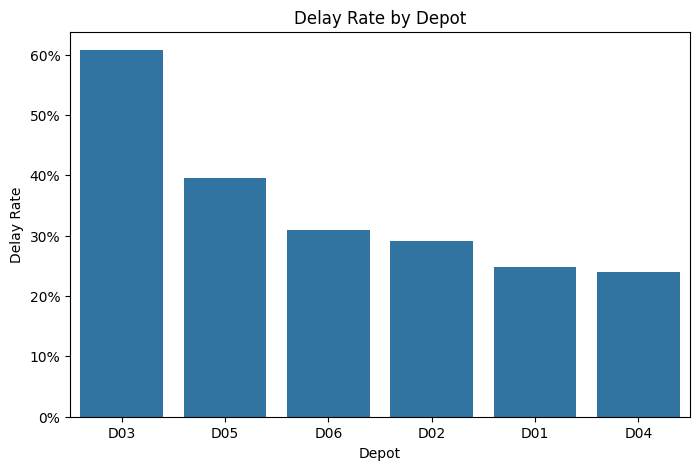

Interpretation:
What this bar graph shows is the delay rate by depot for all depots.
It shows, in descending order from left to right, the depots with the highest delay rate (DO3) to the lowest delay rate (DO4).
Recommended further analysis on understanding why DO3 is so much higher in delay rate vs the other depots.


In [104]:
plt.figure(figsize=(8,5))
sns.barplot(data=depot_delay, x="depot_id", y="delayed")
plt.title("Delay Rate by Depot")
plt.xlabel("Depot")
plt.ylabel("Delay Rate")
plt.gca().yaxis.set_major_formatter(
plt.matplotlib.ticker.PercentFormatter(1))
plt.show()

print("Interpretation:")
print("What this bar graph shows is the delay rate by depot for all depots.")
print("It shows, in descending order from left to right, the depots with the highest delay rate (DO3) to the lowest delay rate (DO4).")
print("Recommended further analysis on understanding why DO3 is so much higher in delay rate vs the other depots.")

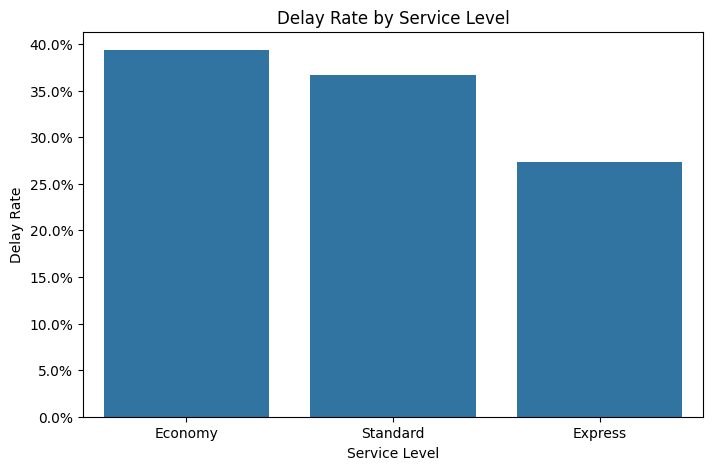

Interpretation:
This bar chart shows the delay rate by service level.
The economy service level has the highest delay rate, while express has the lowest delay rate.
Based on this, it would be recommended to focus primarily on the economy service level and improving that in order to ultimately improve the aggregate delay rate percentage.


In [105]:
plt.figure(figsize=(8,5))
sns.barplot(data=service_delay, x="service_level", y="delayed")
plt.title("Delay Rate by Service Level")
plt.xlabel("Service Level")
plt.ylabel("Delay Rate")
plt.gca().yaxis.set_major_formatter(
plt.matplotlib.ticker.PercentFormatter(1))
plt.show()

print("Interpretation:")
print("This bar chart shows the delay rate by service level.") 
print("The economy service level has the highest delay rate, while express has the lowest delay rate.")
print("Based on this, it would be recommended to focus primarily on the economy service level and improving that in order to ultimately improve the aggregate delay rate percentage.")

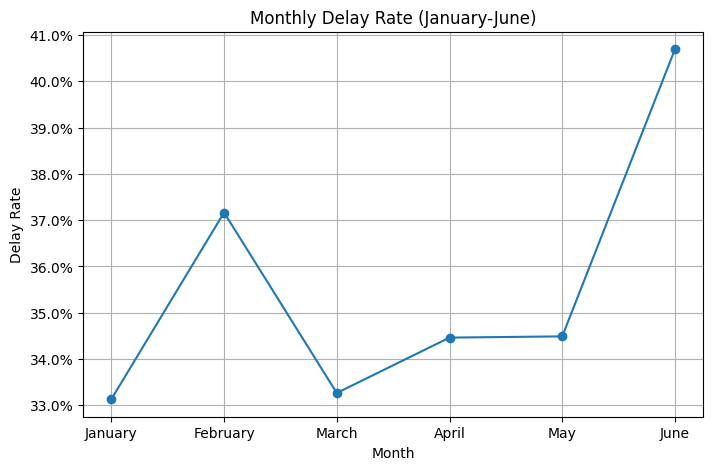

Interpretation:
This line chart shows delay rate by month, from January to June.
There are significant spikes in delay rate from January to Feburary, as well as from May to June.
The delay rate falls from February to March, and remains roughly at the same level up until the spike from May to June.


In [106]:
plt.figure(figsize=(8,5))

monthly_delay.plot(marker="o")
 
plt.title("Monthly Delay Rate (January-June)")

plt.xlabel("Month")

plt.ylabel("Delay Rate")

plt.grid(True)
 
plt.gca().yaxis.set_major_formatter(

plt.matplotlib.ticker.PercentFormatter(1)

)
 
plt.show()

print("Interpretation:")

print("This line chart shows delay rate by month, from January to June.")
print("There are significant spikes in delay rate from January to Feburary, as well as from May to June.")
print("The delay rate falls from February to March, and remains roughly at the same level up until the spike from May to June.")

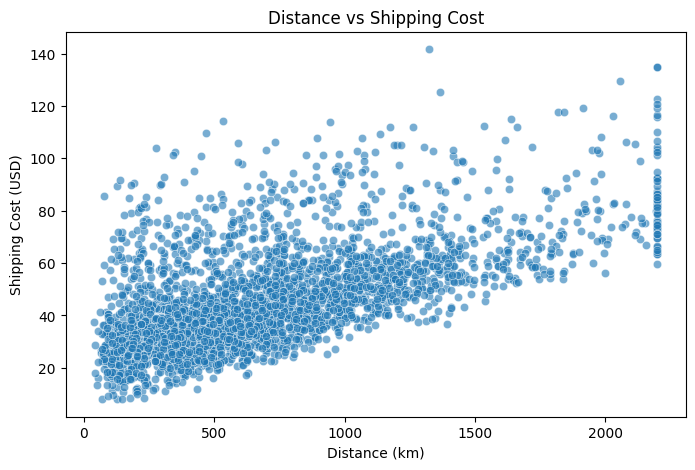

Inerpretation:
This graph is a scatterplot plotting distance in km vs the shipping cost in USD.
Perhaps unsurprisingly, the longer the distance, the higher the shipping cost, generally speaking.
However, there is quite a noticeable variation in shipping cost among packages shipped at greater than 2,000 km. Between ~140 USD and ~60 USD.
It appears that the majority of shipping volume is between 0 and 1,250 km, with the majority of shipping cost being below 60-70 USD.


In [107]:
plt.figure(figsize=(8,5))
 
sns.scatterplot(

    data=analysis_table,

    x="distance_km",

    y="shipping_cost_usd",

    alpha=0.6

)
 
plt.title("Distance vs Shipping Cost")

plt.xlabel("Distance (km)")

plt.ylabel("Shipping Cost (USD)")

plt.show()
 
print("Inerpretation:")
print("This graph is a scatterplot plotting distance in km vs the shipping cost in USD.")
print("Perhaps unsurprisingly, the longer the distance, the higher the shipping cost, generally speaking.")
print("However, there is quite a noticeable variation in shipping cost among packages shipped at greater than 2,000 km. Between ~140 USD and ~60 USD.")
print("It appears that the majority of shipping volume is between 0 and 1,250 km, with the majority of shipping cost being below 60-70 USD.")

# 7 Machine Learning: Predict Delays

##### 1.) Seperate Features 'X' and target 'y'

In [108]:
y = analysis_table["delayed"]
X = analysis_table[
[
"distance_km",
"weight_kg",
"service_level",
"package_type",
"weekend_pickup",
"weather_condition",
"depot_id",
"customer_segment"
]
]
 
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 42)

##### 2.) Split the data into training and test sets
##### 3.) Use `random_state=42` so results can be reproduced.
##### 4.) Use `stratify=y` if you learned how to do so.

In [109]:
#

X_train, X_test, y_train, y_test = train_test_split(X,y,
test_size=0.20, 
random_state=42, 
stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2400, 8)
X_test: (600, 8)
y_train: (2400,)
y_test: (600,)


##### 5.) Encode categorical variables.

In [110]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
 

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

##### 6.) Scale numeric variables if your chosen workflow requires it.

In [111]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### 7.) Fit a logistic regression model.

In [112]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

##### 8.) Generate test-set predictions.

In [113]:
y_pred = model.predict(X_test)
print(y_pred[:20])

[0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0]


##### 9.) Evaluate the model using:
   - Accuracy
   - Precision
   - Recall
   - Confusion matrix

In [118]:
# Accuracy

print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred)}')
print(f'Precision: {metrics.precision_score(y_test, y_pred)}')
print(f'Recall / Sensitivity / True Positive Rate (TPR): {metrics.recall_score(y_test, y_pred)}')


Accuracy: 0.6966666666666667
Precision: 0.6131386861313869
Recall / Sensitivity / True Positive Rate (TPR): 0.39436619718309857


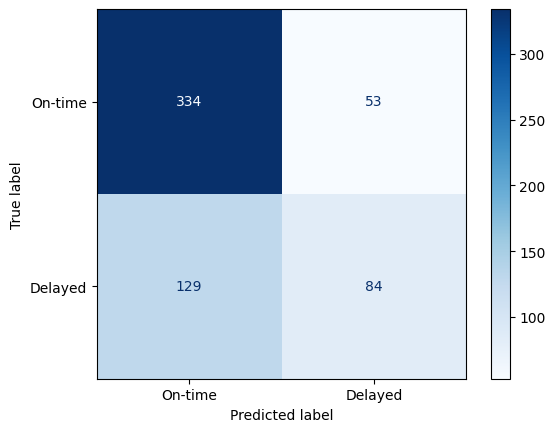

In [120]:
# Confusion Matrix 
class_names = ['On-time', 'Delayed']
 
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
                                 display_labels=class_names,
                                 cmap=plt.cm.Blues);

##### 10.) Compare model accuracy with a simple baseline that predicts the most common class. ***Continue Here (Confirm this is classifcation)

In [121]:
from sklearn.dummy import DummyClassifier
 
dummy_clf = DummyClassifier(strategy="most_frequent")
 
 
dummy_clf.fit(X_train, y_train)
dummy_clf.predict(X_test)
dummy_clf.score(X_test, y_test)

0.645

##### 11.) Explain which features appear to increase or reduce delay risk.